# Golden test — benchmark de modelos del detector de cabezas

Evalúa **cualquier** modelo entrenado contra el **golden test set congelado v2** (151 frames, 1271 cabezas).
Métrica que decide: **count-MAE** (error absoluto medio de conteo por frame) + sesgo (sobre/sub-cuenta) + desglose por cámara.
Réplica fiel de `data/golden/eval_golden.py`, en formato reutilizable.

> **Corre dentro del contenedor `mot-dev`** (JupyterLab con GPU + ultralytics). Rutas = `/workspace`.
> Autodescubre todos los `outputs/head_detector/*/weights/best.pt` + el base, así que cuando entrenes
> un modelo nuevo, esta evaluación lo incluye sola.

**Modelo desplegado hoy en CVAT = MIN5** (función Nuclio `yolov5mu-head`): count-MAE **1.83**.
**Mejor MAE medido = YOLO26X-MIN5: 1.64** — NO desplegado: la ventaja es limítrofe
(Wilcoxon p=0.043, un solo seed). Requiere repetir con 3 seeds antes de promoverlo.

Config fija: `conf=0.25`, `iou(NMS)=0.5` (el validado — no subir el iou).

> ⚠️ **La columna `P` (y `R`) NO son comparables entre modelos.** `yolo val` las reporta en el punto
> de máximo F1 *de cada modelo*, que es un umbral distinto para cada fila. Para comparar modelos entre
> sí usá **MAE**, **sesgo** y **mAP50**, o `scripts/eval/compare_golden_versions.py` (conf fijo + matcher propio).

> ⚠️ Si el BASE falla con `ModuleNotFoundError: dill`, el contenedor necesita `pip install dill`:
> `models/yolov5mu-head-base.pt` fue serializado con dill. Y lanzá el contenedor con `--shm-size=8g`
> o el DataLoader muere con `No space left on device` en `/dev/shm`.


## 0. Configuración y descubrimiento de modelos

In [1]:
import os, glob
from pathlib import Path
import numpy as np
os.environ.setdefault('YOLO_CONFIG_DIR', '/tmp/Ultralytics')

REPO = Path('/workspace')
GOLD = REPO / 'data' / 'golden'
CONF, NMS, IMGSZ = 0.25, 0.5, 640

# --- autodescubrir modelos ---
MODELS = {}
base = REPO / 'models' / 'yolov5mu-head-base.pt'
if base.exists():
    MODELS['BASE'] = base
for w in sorted((REPO / 'outputs' / 'head_detector').glob('*/weights/best.pt')):
    name = w.parent.parent.name.replace('yolo-bus-head-', '').upper()
    MODELS[name] = w

# Para comparar solo algunos, descomenta y ajusta:
# SELECT = ['R5', 'MIN5']
SELECT = None
if SELECT:
    MODELS = {k: v for k, v in MODELS.items() if k in SELECT}

assert GOLD.exists(), f'no existe {GOLD}'
print('Golden:', GOLD)
print(f'conf={CONF}  iou(NMS)={NMS}\n')
print('Modelos a evaluar:')
for k, v in MODELS.items():
    print(f'  {k:8s} {v}')

Golden: /workspace/data/golden
conf=0.25  iou(NMS)=0.5

Modelos a evaluar:
  BASE     /workspace/models/yolov5mu-head-base.pt
  V5MU-COCO-MIN5 /workspace/outputs/head_detector/v5mu-coco-min5/weights/best.pt
  MIN5     /workspace/outputs/head_detector/yolo-bus-head-min5/weights/best.pt
  R1       /workspace/outputs/head_detector/yolo-bus-head-r1/weights/best.pt
  R2       /workspace/outputs/head_detector/yolo-bus-head-r2/weights/best.pt
  R3       /workspace/outputs/head_detector/yolo-bus-head-r3/weights/best.pt
  R4       /workspace/outputs/head_detector/yolo-bus-head-r4/weights/best.pt
  R5       /workspace/outputs/head_detector/yolo-bus-head-r5/weights/best.pt
  YOLO26M-CROWDHUMAN-HEAD4 /workspace/outputs/head_detector/yolo26m-crowdhuman-head4/weights/best.pt
  YOLO26M-MIN5 /workspace/outputs/head_detector/yolo26m-min5/weights/best.pt
  YOLO26S-CROWDHUMAN-HEAD /workspace/outputs/head_detector/yolo26s-crowdhuman-head/weights/best.pt
  YOLO26X-MIN5 /workspace/outputs/head_detector/yolo

## 1. Cargar el ground-truth del golden

In [2]:
def gt_counts():
    d = {}
    for lf in glob.glob(f'{GOLD}/labels/val/*.txt'):
        d[os.path.basename(lf)[:-4]] = sum(1 for ln in open(lf) if len(ln.split()) == 5)
    return d

def cam_of(stem):                      # golden_<cam>_fXXXXXX
    return stem.split('_f')[0].replace('golden_', '')

gt   = gt_counts()
imgs = sorted(glob.glob(f'{GOLD}/images/val/*.jpg'))
print(f'{len(imgs)} imágenes · {sum(gt.values())} cabezas reales')
print('cámaras:', sorted({cam_of(os.path.basename(p)[:-4]) for p in imgs}))

151 imágenes · 1271 cabezas reales
cámaras: ['S08', 'v05', 'v16', 'video02']


## 2. Evaluar (P/R/mAP + count-MAE por modelo)

Para cada modelo: métricas de detección con `yolo val`, y el error de conteo prediciendo frame a frame.

In [3]:
import cv2
from ultralytics import YOLO

rows = []
for name, mp in MODELS.items():
    print(f'>>> {name} ...', flush=True)
    m = YOLO(str(mp))
    # --- detección ---
    met = m.val(data=str(GOLD / 'golden.yaml'), imgsz=IMGSZ, conf=CONF, iou=NMS,
                workers=2, verbose=False, plots=False)
    P, R, mAP50, mAP = met.box.mp, met.box.mr, met.box.map50, met.box.map
    # --- conteo ---
    abs_err, bias, per_cam = [], [], {}
    for p in imgs:
        stem = os.path.basename(p)[:-4]
        pred = len(m.predict(cv2.imread(p), conf=CONF, iou=NMS, verbose=False)[0].boxes)
        e = pred - gt.get(stem, 0)
        abs_err.append(abs(e)); bias.append(e)
        per_cam.setdefault(cam_of(stem), []).append(abs(e))
    rows.append({
        'modelo': name, 'P': P, 'R': R, 'mAP50': mAP50, 'mAP50-95': mAP,
        'MAE': float(np.mean(abs_err)), 'sesgo': float(np.mean(bias)),
        'por_camara': {c: round(float(np.mean(v)), 2) for c, v in sorted(per_cam.items())},
    })
print('\n✅ listo')

WARNING ⚠️ user config directory '/tmp/Ultralytics/Ultralytics' is not writable, using '/tmp/Ultralytics'. Set YOLO_CONFIG_DIR to override.


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/tmp/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


>>> BASE ...


Ultralytics 8.4.0 🚀 Python-3.10.14 torch-2.2.2 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 15927MiB)


YOLOv5m summary (fused): 106 layers, 25,045,795 parameters, 0 gradients, 64.0 GFLOPs


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 90% ━━━━━━━━━━╸─ 9/10 2.7it/s 3.2s<0.4s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.9it/s 3.4s

                   all        151       1271      0.908      0.762      0.854      0.571


Speed: 0.3ms preprocess, 21.5ms inference, 0.0ms loss, 0.0ms postprocess per image



✅ listo


## 3. Tabla de resultados (ordenada por count-MAE, menor = mejor)

In [4]:
import pandas as pd

DEPLOYED = 'MIN5'   # el que hoy sirve en CVAT (funcion Nuclio yolov5mu-head)

df = (pd.DataFrame(rows)
        .sort_values('MAE')
        .reset_index(drop=True))
show = df[['modelo', 'MAE', 'sesgo', 'R', 'mAP50', 'mAP50-95', 'P']].copy()
for c in ['MAE', 'sesgo', 'R', 'mAP50', 'mAP50-95', 'P']:
    show[c] = show[c].map(lambda x: f'{x:.3f}' if c not in ('MAE', 'sesgo') else f'{x:+.2f}' if c == 'sesgo' else f'{x:.2f}')
print(f'GOLDEN TEST v2 — conf {CONF} / iou {NMS}  ·  desplegado: {DEPLOYED}\n')
print(show.to_string(index=False))
print('\n(P y R no son comparables entre filas: yolo val las mide en el maximo F1 de cada modelo)')

best = df.iloc[0]
print(f"\nmejor count-MAE: {best['modelo']} = {best['MAE']:.2f}  (sesgo {best['sesgo']:+.2f})")
if DEPLOYED in df['modelo'].values:
    cur = df[df.modelo == DEPLOYED].iloc[0]['MAE']
    if best['modelo'] != DEPLOYED:
        d = cur - best['MAE']
        print(f"   vs {DEPLOYED} ({cur:.2f}): delta={d:+.2f}")
        print("   OJO: una diferencia de count-MAE de un solo seed NO alcanza para desplegar.")
        print("   Repetir con 3 seeds y test de significancia antes de promover.")

# todos sub-cuentan? (sesgo negativo = el modelo ve menos cabezas de las que hay)
n_bajo = (df['sesgo'] < 0).sum()
print(f"\nmodelos que SUB-cuentan: {n_bajo}/{len(df)}  (sesgo de {df.sesgo.min():.2f} a {df.sesgo.max():.2f})")


GOLDEN TEST v2 — conf 0.25 / iou 0.5  ·  desplegado: MIN5

                  modelo  MAE sesgo     R mAP50 mAP50-95     P
            YOLO26X-MIN5 1.64 -1.36 0.762 0.854    0.571 0.908
          V5MU-COCO-MIN5 1.76 -1.52 0.745 0.845    0.564 0.906
                    MIN5 1.83 -1.57 0.801 0.872    0.625 0.889
            YOLO26M-MIN5 1.91 -1.81 0.732 0.837    0.559 0.898
                      R5 2.17 -2.07 0.780 0.868    0.620 0.908
                      R3 2.21 -2.09 0.747 0.849    0.642 0.902
                      R4 2.69 -2.60 0.745 0.855    0.694 0.931
                      R2 4.36 -4.31 0.502 0.684    0.415 0.866
                    BASE 5.32 -5.32 0.308 0.590    0.320 0.852
YOLO26M-CROWDHUMAN-HEAD4 5.45 -5.44 0.253 0.535    0.320 0.811
 YOLO26S-CROWDHUMAN-HEAD 5.85 -5.85 0.232 0.539    0.284 0.831
                      R1 7.05 -7.05 0.135 0.445    0.201 0.767

(P y R no son comparables entre filas: yolo val las mide en el maximo F1 de cada modelo)

mejor count-MAE: YOLO26X-MIN5 =

## 4. Desglose por cámara

`video02` es la cámara **no vista** en entrenamiento → el mejor termómetro de generalización.

In [5]:
cam_df = pd.DataFrame({r['modelo']: r['por_camara'] for r in rows}).T
cam_df = cam_df.reindex(df['modelo'].values)   # mismo orden que la tabla principal
print('MAE por cámara (menor = mejor):\n')
print(cam_df.to_string())

MAE por cámara (menor = mejor):

                           S08   v05   v16  video02
YOLO26X-MIN5              1.18  1.29  1.24     1.85
V5MU-COCO-MIN5            1.59  1.24  0.76     2.05
MIN5                      1.35  1.47  1.47     2.04
YOLO26M-MIN5              1.53  2.00  1.35     2.06
R5                        1.41  1.65  1.24     2.55
R3                        0.94  1.82  1.65     2.58
R4                        1.47  2.53  2.12     3.02
R2                        3.24  5.53  3.82     4.45
BASE                      4.76  5.47  5.29     5.40
YOLO26M-CROWDHUMAN-HEAD4  4.29  5.41  4.47     5.82
YOLO26S-CROWDHUMAN-HEAD   5.06  5.35  4.88     6.24
R1                        5.59  7.71  7.18     7.16


## 5. Gráficos

Tres vistas para presentar: ranking por count-MAE, generalización por cámara, y la curva de progreso
del proyecto ronda a ronda. Los PNG quedan en `outputs/golden_eval/`.

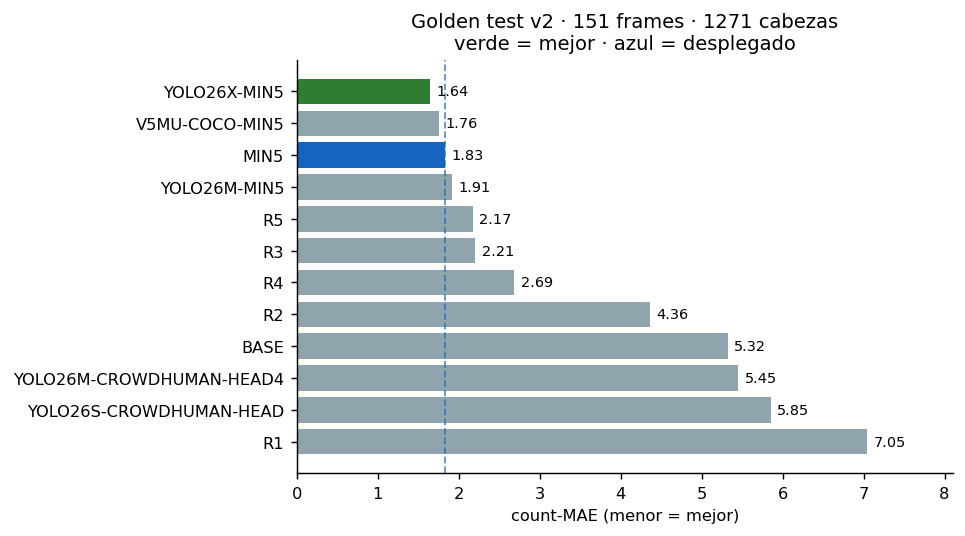

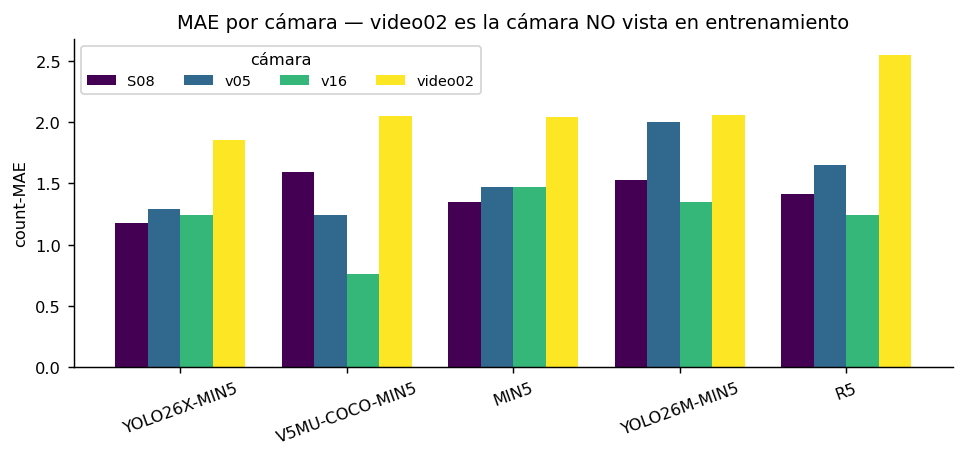

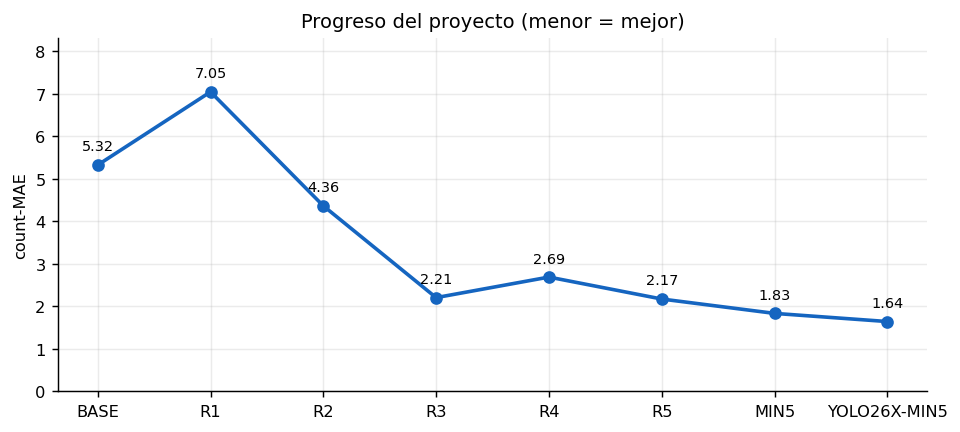

PNG guardados en /workspace/outputs/golden_eval


In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
from pathlib import Path

OUT = REPO / 'outputs' / 'golden_eval'
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 130, 'font.size': 9})

dep = df[df.modelo == DEPLOYED]['MAE'].iloc[0] if DEPLOYED in df['modelo'].values else None

# ---- 1. ranking por count-MAE ----
d = df.sort_values('MAE', ascending=False)
colors = ['#2e7d32' if m == d.iloc[-1]['modelo'] else '#1565c0' if m == DEPLOYED else '#90a4ae'
          for m in d['modelo']]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.barh(d['modelo'], d['MAE'], color=colors)
for y, v in zip(d['modelo'], d['MAE']):
    ax.text(v + 0.08, y, f'{v:.2f}', va='center', fontsize=8)
if dep is not None:
    ax.axvline(dep, color='#1565c0', ls='--', lw=1, alpha=.7)
ax.set_xlabel('count-MAE (menor = mejor)')
ax.set_title(f'Golden test v2 · {len(imgs)} frames · {sum(gt.values())} cabezas\nverde = mejor · azul = desplegado')
ax.set_xlim(0, d['MAE'].max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout(); fig.savefig(OUT / 'mae_ranking.png'); plt.show()

# ---- 2. MAE por camara (top 5) ----
top = df.head(5)['modelo'].tolist()
sub = cam_df.loc[top] if 'cam_df' in dir() else pd.DataFrame({r['modelo']: r['por_camara'] for r in rows}).T.loc[top]
fig, ax = plt.subplots(figsize=(7.5, 3.6))
sub.plot(kind='bar', ax=ax, width=.78, colormap='viridis')
ax.set_ylabel('count-MAE'); ax.set_xlabel('')
ax.set_title('MAE por cámara — video02 es la cámara NO vista en entrenamiento')
ax.legend(title='cámara', fontsize=8, ncol=4)
ax.tick_params(axis='x', rotation=20)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout(); fig.savefig(OUT / 'mae_por_camara.png'); plt.show()

# ---- 3. curva de progreso del proyecto ----
orden = [m for m in ['BASE', 'R1', 'R2', 'R3', 'R4', 'R5', 'MIN5', 'YOLO26X-MIN5'] if m in df['modelo'].values]
serie = [df[df.modelo == m]['MAE'].iloc[0] for m in orden]
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(orden, serie, marker='o', color='#1565c0', lw=2)
for x, y in zip(orden, serie):
    ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
ax.set_ylabel('count-MAE'); ax.set_title('Progreso del proyecto (menor = mejor)')
ax.grid(alpha=.25); ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, max(serie) * 1.18)
fig.tight_layout(); fig.savefig(OUT / 'progreso.png'); plt.show()

print('PNG guardados en', OUT)
